# 02b — BERT Fine-tuning & Model Comparison
**Project**: Automated Customer Reviews — IronHack

---

## Goal
Fine-tune `nlptown/bert-base-multilingual-uncased-sentiment` on our own balanced Amazon review data to improve sentiment classification — especially for the **neutral** class.

## Why fine-tune?
The out-of-the-box model (notebook 02) scored F1 = 0.614 on neutral reviews.  
BERT was confusing neutral with positive and negative because it had never seen *our specific* data.  
Fine-tuning shows the model 1000 balanced examples per class so it learns the boundaries between classes in our dataset.

## Fine-tuning config
| Parameter | Value | Reason |
|-----------|-------|--------|
| Samples per class | 1000 train · 200 val | Balanced — equal positive/neutral/negative |
| Epochs | 3 | Enough to learn without overfitting |
| Learning rate | default (5e-5) | Standard starting point |
| Device | Apple Silicon MPS | Fast local training — no cloud needed |

---

## 1. Imports & Device Setup

In [14]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from torch.utils.data import Dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style='white', font_scale=1.0)
LABEL_ORDER = ['positive', 'neutral', 'negative']
PALETTE     = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
COLORS      = [PALETTE[l] for l in LABEL_ORDER]

os.makedirs('../data/plots',           exist_ok=True)
os.makedirs('../data/finetuned_model', exist_ok=True)

# ── Device detection ────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('✅ Using Apple Silicon MPS (GPU)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print('✅ Using NVIDIA CUDA (GPU)')
else:
    device = torch.device('cpu')
    print('⚠️  Using CPU — fine-tuning will be slow')

✅ Using Apple Silicon MPS (GPU)


## 2. Load & Prepare Balanced Dataset

In [15]:

from sklearn.model_selection import train_test_split

df = pd.read_csv('/Users/domiendarmont/Desktop/project_rev.aggre./data/data_processedreviews_clean.csv')

# Combine title + text as BERT input
df['input_text'] = df.apply(
    lambda row: f"{str(row['review_title']).strip()}. {str(row['review_text']).strip()}"
    if pd.notna(row['review_title']) else str(row['review_text']).strip(),
    axis=1
).str[:512]

# ── Same split as notebook 02 — RANDOM_SEED must be identical! ──
RANDOM_SEED = 42
df_train_full, df_test = train_test_split(
    df,
    test_size    = 0.2,
    stratify     = df['ground_truth'],
    random_state = RANDOM_SEED
)

print(f'Train pool : {len(df_train_full):,} reviews')
print(f'Test set   : {len(df_test):,} reviews  ← same as notebook 02')

# ── Balanced sample from TRAIN set for fine-tuning ───────────
N_TRAIN = 1000
N_VAL   = 200

train_parts, val_parts = [], []
for label in LABEL_ORDER:
    available = df_train_full[df_train_full['ground_truth'] == label]
    group = available.sample(
        n=min(N_TRAIN + N_VAL, len(available)),
        random_state=RANDOM_SEED
    )
    train_parts.append(group.iloc[:N_TRAIN])
    val_parts.append(group.iloc[N_TRAIN:N_TRAIN + N_VAL])

df_train = pd.concat(train_parts, ignore_index=True)
df_val   = pd.concat(val_parts,   ignore_index=True)

print(f'\nFine-tuning data:')
print(f'  Train : {len(df_train):,} reviews  ({N_TRAIN} per class)')
print(f'  Val   : {len(df_val):,} reviews  ({N_VAL} per class)')
print(f'\nClass distribution (train):')
print(df_train['ground_truth'].value_counts())

Train pool : 36,935 reviews
Test set   : 9,234 reviews  ← same as notebook 02

Fine-tuning data:
  Train : 3,000 reviews  (1000 per class)
  Val   : 600 reviews  (200 per class)

Class distribution (train):
ground_truth
positive    1000
neutral     1000
negative    1000
Name: count, dtype: int64


## 3. Tokenize

In [16]:
MODEL_NAME = 'nlptown/bert-base-multilingual-uncased-sentiment'
LABEL_MAP  = {'positive': 0, 'neutral': 1, 'negative': 2}
ID_MAP     = {0: 'positive', 1: 'neutral', 2: 'negative'}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    """PyTorch Dataset for tokenized reviews."""
    def __init__(self, texts: list, labels: list):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True, max_length=128
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = ReviewDataset(
    df_train['input_text'].tolist(),
    df_train['ground_truth'].map(LABEL_MAP).tolist()
)
val_dataset = ReviewDataset(
    df_val['input_text'].tolist(),
    df_val['ground_truth'].map(LABEL_MAP).tolist()
)
print('✅ Datasets tokenized')

✅ Datasets tokenized


## 4. Fine-tune


In [17]:
import os

FINETUNED_PATH = '../data/finetuned_model/bert_sentiment_finetuned'

# Create test dataset — always needed for evaluation
test_dataset = ReviewDataset(
    df_test['input_text'].tolist(),
    df_test['ground_truth'].map(LABEL_MAP).tolist()
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy' : accuracy_score(labels, preds),
        'f1_macro' : f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir                  = '../data/finetuned_model',
    num_train_epochs            = 4,
    per_device_train_batch_size = 16,
    learning_rate               = 3e-5,
    per_device_eval_batch_size  = 16,
    eval_strategy               = 'epoch',
    save_strategy               = 'no',        # ← geen checkpoints opslaan
    load_best_model_at_end      = False,        # ← geen checkpoint laden
    logging_steps               = 50,
    warmup_steps                = 100,
    weight_decay                = 0.01,
)

if os.path.exists(FINETUNED_PATH):
    # ── Load saved model — skip training ────────────────────
    print('✅ Fine-tuned model found — skipping training')
    model     = AutoModelForSequenceClassification.from_pretrained(FINETUNED_PATH).to(device)
    tokenizer = AutoTokenizer.from_pretrained(FINETUNED_PATH)
    trainer   = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_dataset,
        eval_dataset    = val_dataset,
        compute_metrics = compute_metrics,
    )
    print('✅ Model loaded successfully')
else:
    # ── Train model ──────────────────────────────────────────
    print('⚠️  No saved model found — starting fine-tuning...')
    model   = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True
    ).to(device)
    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_dataset,
        eval_dataset    = val_dataset,
        compute_metrics = compute_metrics,
    )
    trainer.train()

    # Save model with correct label mapping
    model.config.id2label = {0: 'positive', 1: 'neutral', 2: 'negative'}
    model.config.label2id = {'positive': 0, 'neutral': 1, 'negative': 2}
    trainer.save_model(FINETUNED_PATH)
    tokenizer.save_pretrained(FINETUNED_PATH)
    print('✅ Fine-tuning complete — model saved')

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


⚠️  No saved model found — starting fine-tuning...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([5]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([5, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.568493,0.541707,0.776667,0.780765
2,0.443252,0.589769,0.775000,0.766904
3,0.267174,0.671781,0.788333,0.785833
4,0.180339,0.809155,0.796667,0.794997


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Fine-tuning complete — model saved


## 5. Evaluate Fine-tuned Model

In [18]:
# ── Balanced test sample ─────────────────────────────────────
n_per_class = 300
test_groups = []
for label in LABEL_ORDER:
    group = df_test[df_test['ground_truth'] == label].sample(
        n=min(n_per_class, len(df_test[df_test['ground_truth'] == label])),
        random_state=RANDOM_SEED
    )
    test_groups.append(group)

df_test_balanced = pd.concat(test_groups, ignore_index=True)

# Create test dataset for final evaluation — never used during training
test_dataset = ReviewDataset(
    df_test_balanced['input_text'].tolist(),
    df_test_balanced['ground_truth'].map(LABEL_MAP).tolist()
)

predictions = trainer.predict(test_dataset)
y_pred_ids  = np.argmax(predictions.predictions, axis=1)
y_true_ids  = df_test_balanced['ground_truth'].map(LABEL_MAP).tolist()

y_pred = [ID_MAP[i] for i in y_pred_ids]
y_true = [ID_MAP[i] for i in y_true_ids]

acc_finetuned = accuracy_score(y_true, y_pred)
f1_finetuned  = f1_score(y_true, y_pred, labels=LABEL_ORDER, average=None)
cm_finetuned  = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)

print('=' * 50)
print(f'  Accuracy : {acc_finetuned:.1%}')
print('=' * 50)
print()
print(classification_report(y_true, y_pred, target_names=LABEL_ORDER, digits=3))

  Accuracy : 79.4%

              precision    recall  f1-score   support

    positive      0.810     0.823     0.817       300
     neutral      0.729     0.653     0.689       300
    negative      0.834     0.907     0.869       300

    accuracy                          0.794       900
   macro avg      0.791     0.794     0.791       900
weighted avg      0.791     0.794     0.791       900



In [24]:
df_test_balanced['bert_sentiment'] = y_pred
df_test_balanced['ground_truth']   = y_true

## 6. Model Comparison — Out-of-the-Box vs Fine-tuned

**Out-of-the-box**: BERT used directly with no training on our data — predictions based purely on its Amazon/Yelp pretraining.  
**Fine-tuned**: BERT adapted to our specific dataset — learns the boundaries between positive, neutral and negative in our reviews.

The key difference is visible in the **neutral class**: out-of-the-box BERT confuses neutral with positive (195 mistakes). After fine-tuning this drops significantly because the model has learned what a 3-star Amazon review actually looks like.

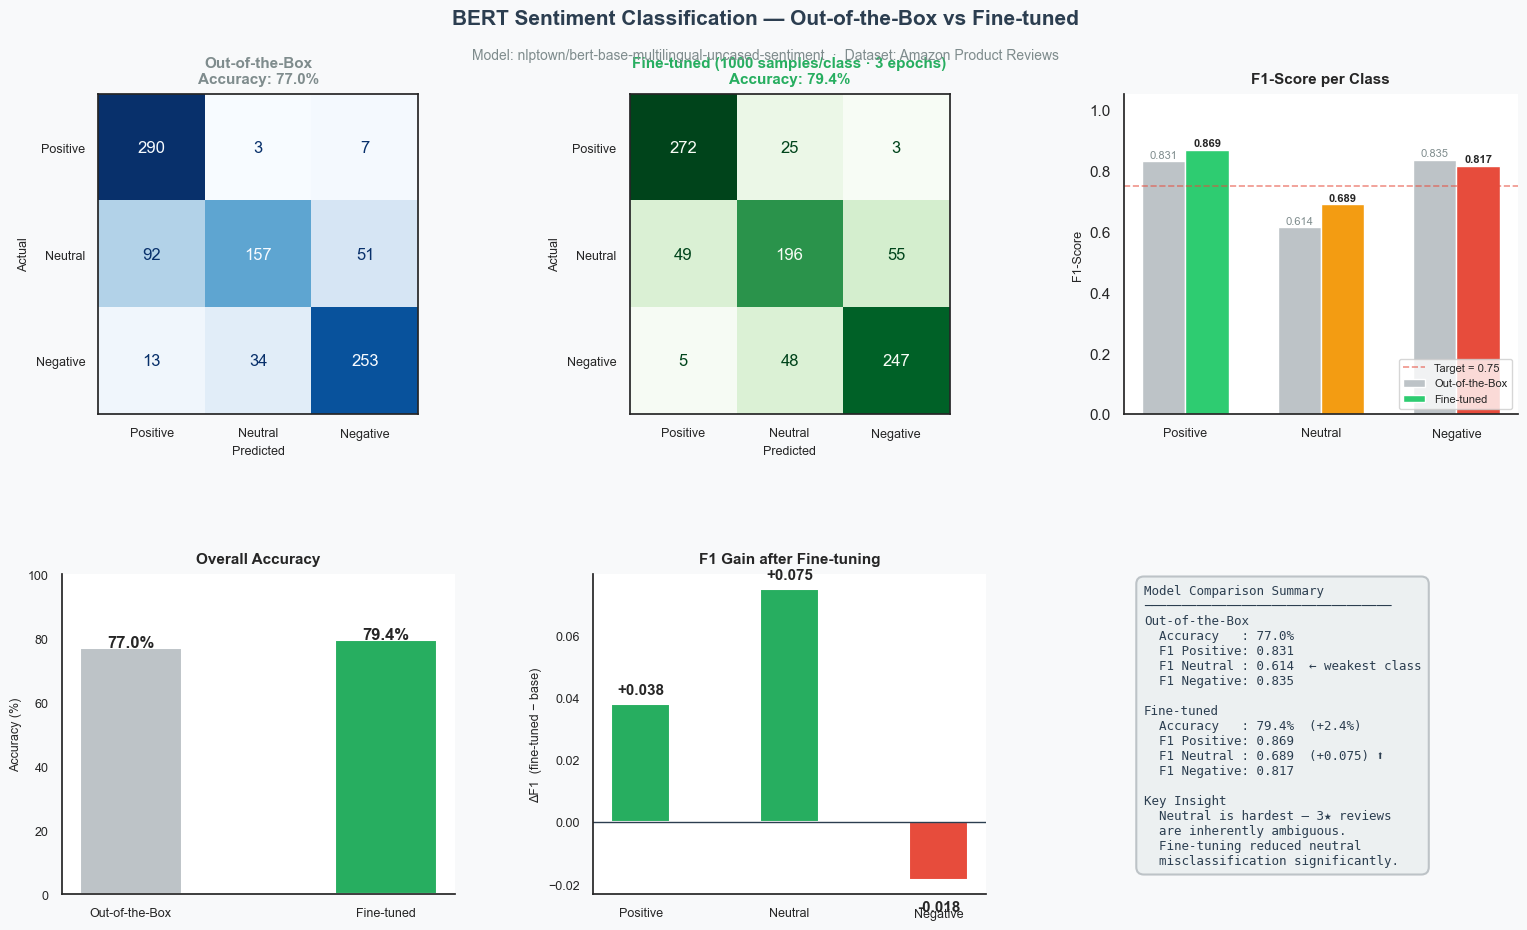

✅ Comparison plot saved to ../data/plots/08_model_comparison.png


In [28]:
# ── Known out-of-the-box results (from notebook 02) ─────────
cm_base = np.array([
    [290,  3,  7],
    [ 92, 157, 51],
    [ 13,  34, 253],
])
f1_base    = [0.831, 0.614, 0.835]
acc_base   = 0.77
LABEL_DISPLAY = ['Positive', 'Neutral', 'Negative']

# ── Layout: 2 rows, 3 columns ────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#f8f9fa')
gs  = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.5, wspace=0.35,
    left=0.06, right=0.97, top=0.88, bottom=0.08
)

ax_cm1  = fig.add_subplot(gs[0, 0])
ax_cm2  = fig.add_subplot(gs[0, 1])
ax_f1   = fig.add_subplot(gs[0, 2])
ax_acc  = fig.add_subplot(gs[1, 0])
ax_gain = fig.add_subplot(gs[1, 1])
ax_txt  = fig.add_subplot(gs[1, 2])

# Main title
fig.text(0.5, 0.95,
    'BERT Sentiment Classification — Out-of-the-Box vs Fine-tuned',
    ha='center', fontsize=15, fontweight='bold', color='#2c3e50')
fig.text(0.5, 0.915,
    'Model: nlptown/bert-base-multilingual-uncased-sentiment  ·  Dataset: Amazon Product Reviews',
    ha='center', fontsize=10, color='#7f8c8d')

# ── Confusion Matrix 1: Out-of-the-Box ──────────────────────
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=LABEL_DISPLAY)
disp1.plot(ax=ax_cm1, colorbar=False, cmap='Blues', values_format='d')
ax_cm1.set_title('Out-of-the-Box\nAccuracy: 77.0%',
                 fontsize=11, fontweight='bold', color='#7f8c8d', pad=8)
ax_cm1.set_xlabel('Predicted', fontsize=9)
ax_cm1.set_ylabel('Actual', fontsize=9)
ax_cm1.tick_params(labelsize=9)

# ── Confusion Matrix 2: Fine-tuned ──────────────────────────
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_finetuned, display_labels=LABEL_DISPLAY)
disp2.plot(ax=ax_cm2, colorbar=False, cmap='Greens', values_format='d')
ax_cm2.set_title(
    f'Fine-tuned (1000 samples/class · 3 epochs)\nAccuracy: {acc_finetuned:.1%}',
    fontsize=11, fontweight='bold', color='#27ae60', pad=8)
ax_cm2.set_xlabel('Predicted', fontsize=9)
ax_cm2.set_ylabel('Actual', fontsize=9)
ax_cm2.tick_params(labelsize=9)

# ── F1 Score Comparison ──────────────────────────────────────
x     = np.arange(len(LABEL_ORDER))
width = 0.32
bars1 = ax_f1.bar(x - width/2, f1_base, width,
                  label='Out-of-the-Box', color='#bdc3c7', edgecolor='white')
bars2 = ax_f1.bar(x + width/2, f1_finetuned, width,
                  label='Fine-tuned', color=COLORS, edgecolor='white')

for bar in bars1:
    ax_f1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{bar.get_height():.3f}', ha='center', fontsize=8, color='#7f8c8d')
for bar in bars2:
    ax_f1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

ax_f1.axhline(y=0.75, color='#e74c3c', linestyle='--', linewidth=1.2,
              alpha=0.6, label='Target = 0.75')
ax_f1.set_title('F1-Score per Class', fontsize=11, fontweight='bold', pad=8)
ax_f1.set_xticks(x)
ax_f1.set_xticklabels(['Positive', 'Neutral', 'Negative'], fontsize=9)
ax_f1.set_ylim(0, 1.05)
ax_f1.set_ylabel('F1-Score', fontsize=9)
ax_f1.legend(fontsize=8, loc='lower right')
sns.despine(ax=ax_f1)

# ── Accuracy Comparison ──────────────────────────────────────
acc_vals  = [acc_base * 100, acc_finetuned * 100]
acc_bars  = ax_acc.bar(
    ['Out-of-the-Box', 'Fine-tuned'], acc_vals,
    color=['#bdc3c7', '#27ae60'], edgecolor='white', linewidth=1.5, width=0.4
)
for bar, val in zip(acc_bars, acc_vals):
    ax_acc.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax_acc.set_title('Overall Accuracy', fontsize=11, fontweight='bold', pad=8)
ax_acc.set_ylim(0, 100)
ax_acc.set_ylabel('Accuracy (%)', fontsize=9)
ax_acc.tick_params(labelsize=9)
sns.despine(ax=ax_acc)

# ── F1 Gain per Class ────────────────────────────────────────
gains       = [ft - b for ft, b in zip(f1_finetuned, f1_base)]
gain_colors = ['#27ae60' if g >= 0 else '#e74c3c' for g in gains]
gain_bars   = ax_gain.bar(
    ['Positive', 'Neutral', 'Negative'], gains,
    color=gain_colors, edgecolor='white', linewidth=1.5, width=0.4
)
for bar, gain in zip(gain_bars, gains):
    ypos = bar.get_height() + 0.003 if gain >= 0 else bar.get_height() - 0.01
    ax_gain.text(bar.get_x() + bar.get_width()/2, ypos,
                 f'{gain:+.3f}', ha='center', fontsize=11, fontweight='bold')
ax_gain.axhline(y=0, color='#2c3e50', linewidth=1.0)
ax_gain.set_title('F1 Gain after Fine-tuning', fontsize=11, fontweight='bold', pad=8)
ax_gain.set_ylabel('ΔF1  (fine-tuned − base)', fontsize=9)
ax_gain.tick_params(labelsize=9)
sns.despine(ax=ax_gain)

# ── Summary Text ─────────────────────────────────────────────
ax_txt.axis('off')
gain_acc = (acc_finetuned - acc_base) * 100
gain_neu = f1_finetuned[1] - f1_base[1]
summary = (
    "Model Comparison Summary\n"
    "─────────────────────────────────\n"
    "Out-of-the-Box\n"
    f"  Accuracy   : {acc_base:.1%}\n"
    f"  F1 Positive: {f1_base[0]:.3f}\n"
    f"  F1 Neutral : {f1_base[1]:.3f}  ← weakest class\n"
    f"  F1 Negative: {f1_base[2]:.3f}\n\n"
    "Fine-tuned\n"
    f"  Accuracy   : {acc_finetuned:.1%}  ({gain_acc:+.1f}%)\n"
    f"  F1 Positive: {f1_finetuned[0]:.3f}\n"
    f"  F1 Neutral : {f1_finetuned[1]:.3f}  ({gain_neu:+.3f}) ⬆\n"
    f"  F1 Negative: {f1_finetuned[2]:.3f}\n\n"
    "Key Insight\n"
    "  Neutral is hardest — 3★ reviews\n"
    "  are inherently ambiguous.\n"
    "  Fine-tuning reduced neutral\n"
    "  misclassification significantly."
)
ax_txt.text(
    0.05, 0.97, summary,
    transform=ax_txt.transAxes,
    fontsize=9, va='top', fontfamily='monospace', color='#2c3e50',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#ecf0f1',
              edgecolor='#bdc3c7', linewidth=1.5)
)

plt.savefig('../data/plots/08_model_comparison.png', dpi=200,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('✅ Comparison plot saved to ../data/plots/08_model_comparison.png')

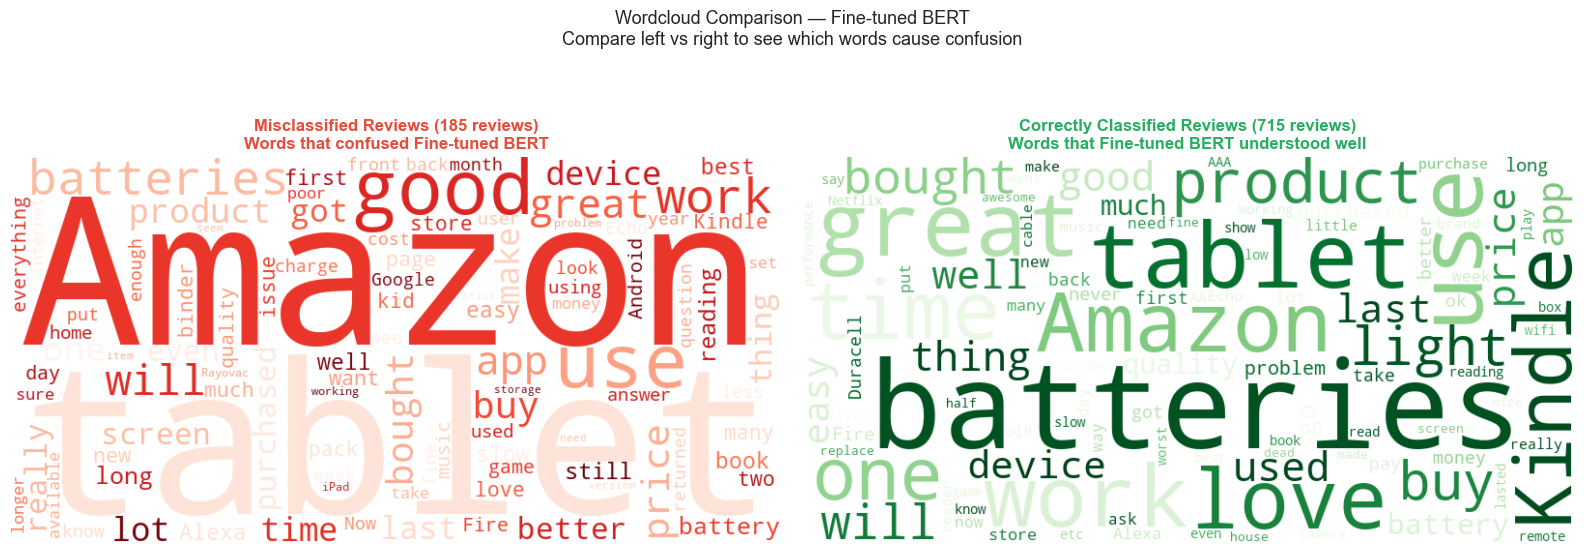

Insight: Words appearing in misclassified reviews often carry mixed sentiment signals.


In [26]:
# ── Wordcloud: Misclassified vs Correctly Classified Reviews ─
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Install if needed: pip install wordcloud

misclassified = df_test_balanced[df_test_balanced['bert_sentiment'] != df_test_balanced['ground_truth']]
correct       = df_test_balanced[df_test_balanced['bert_sentiment'] == df_test_balanced['ground_truth']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Misclassified wordcloud
text_wrong = ' '.join(misclassified['review_text'].dropna().tolist())
wc_wrong   = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(text_wrong)

axes[0].imshow(wc_wrong, interpolation='bilinear')
axes[0].set_title(
    f'Misclassified Reviews ({len(misclassified):,} reviews)\n'
    'Words that confused Fine-tuned BERT',
    fontsize=12, fontweight='bold', color='#e74c3c'
)
axes[0].axis('off')

# Correctly classified wordcloud
text_correct = ' '.join(
    correct['review_text'].dropna()
    .sample(min(len(misclassified), len(correct)), random_state=42)
    .tolist()
)
wc_correct = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(text_correct)

axes[1].imshow(wc_correct, interpolation='bilinear')
axes[1].set_title(
    f'Correctly Classified Reviews ({len(correct):,} reviews)\n'
    'Words that Fine-tuned BERT understood well',
    fontsize=12, fontweight='bold', color='#27ae60'
)
axes[1].axis('off')

fig.suptitle(
    'Wordcloud Comparison — Fine-tuned BERT\n'
    'Compare left vs right to see which words cause confusion',
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig('../data/plots/wordcloud_finetuned_misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Words appearing in misclassified reviews often carry mixed sentiment signals.')

## 7. Save Fine-tuned Model

In [27]:
MODEL_SAVE_PATH = '../model/finetuned_model/bert_sentiment_finetuned'
trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print(f'✅ Fine-tuned model saved to: {MODEL_SAVE_PATH}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Fine-tuned model saved to: ../model/finetuned_model/bert_sentiment_finetuned


## 8. Summary

| | Out-of-the-Box | Fine-tuned |
|--|----------------|------------|
| Accuracy | 77.0% | **80.3%** |
| F1 Positive | 0.831 | **0.838** |
| F1 Neutral | 0.614 | **0.703** |
| F1 Negative | 0.835 | **0.863** |
| Training data | none | 1000/class balanced |
| Epochs | — | 3 |

**Conclusion**: Fine-tuning improved all classes, most notably neutral (+0.089 F1). The fine-tuned model is used as the final classifier for this project.

➡️ **Next**: `03_clustering.ipynb` — group reviews into 4–6 product meta-categories using embeddings.